# MoodSwing — Data Science Pipeline

**Goal:** Build a *Mood-to-Town* recommendation engine using synthetic data.

| Section | Content |
|---|---|
| 1 | Synthetic data generation |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Feature engineering |
| 4 | Model training — RF vs XGBoost |
| 5 | Evaluation & export |
| 6 | Town wordclouds |

## 1 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('data',             exist_ok=True)
os.makedirs('models',           exist_ok=True)
os.makedirs('assets/wordclouds',exist_ok=True)

sns.set_theme(style='whitegrid', palette='pastel')
plt.rcParams['figure.dpi'] = 110
print('Setup complete ✓')

Setup complete ✓


## 2 · Data Generation

Generates `data/synthetic_moods.csv` with realistic per-user behaviour.
Each user has a personality profile controlling how often they feel sad / happy / calm.
Timestamps, notes, and town names match the format of real user data.

- To **regenerate fresh data**, set `FORCE_REGENERATE = True`
- To **keep existing data**, leave it as `False`

In [41]:
import os
from datetime import datetime, timedelta

# ── Toggle this to regenerate fresh data ──────────────────────────────────
FORCE_REGENERATE = False

# ── Configuration ──────────────────────────────────────────────────────────
N_USERS    = 50
DAYS       = 14
START_DATE = datetime(2026, 2, 19)

MOOD_ID  = {'sad': 0, 'happy': 1, 'calm': 2}
TOWN_MAP = {'sad': 'Mist Haven', 'happy': 'Spark City', 'calm': 'Bloom Fields'}

# ── Specific mood words per group ──────────────────────────────────────────
TOWN_MOODS = {
    'positive': ['Joyful', 'Grateful', 'Excited', 'Proud', 'Peaceful', 'Happy'],
    'calming':  ['Tired', 'Angry', 'Anxious', 'Overwhelmed', 'Lost', 'Spiralling'],
    'sad':      ['Sad', 'Lonely', 'Meh', 'Hurt', 'Broken-Hearted', 'Unmotivated', 'Dejected'],
}

NOTES = {
    'happy': [
        'Played with my dog', 'Watched a movie', 'Read a book',
        'Cooked a nice meal', 'Lunch with friends', 'Went for a walk',
        'Had a great workout', 'Family time', 'Enjoyed a sunny afternoon',
        'Caught up with an old friend', 'Finished a project I am proud of',
        'Had a really good laugh today', 'Treated myself to something nice',
        'Woke up feeling great', 'Good news arrived today',
    ],
    'sad': [
        'Couldn t get out of bed today', 'Feeling really low',
        'Miss having someone to talk to', 'Everything feels heavy',
        'Cried and didn t even know why', 'Stayed home all day',
        'Just need some quiet time', 'Hard day, feeling drained',
        'Feeling invisible', 'Not in the mood for anything',
        'Called a friend but no answer', 'Looked through old photos',
        'Felt really alone today', 'Too tired to explain how I feel',
        'Sitting in the dark listening to music',
    ],
    'calm': [
        'Just drifting today', 'Taking things slow', 'Went for a quiet walk',
        'Did some journaling', 'Had a slow morning with tea',
        'Not sure what I want right now', 'Feeling a bit lost but okay',
        'Sat by the window and thought', 'Took a long bath',
        'Nothing planned, just being', 'Feeling uncertain about everything',
        'Quiet evening at home', 'Watched the clouds for a while',
        'Tidied my room, felt a bit clearer', 'Listened to lo-fi and did nothing',
    ],
}

NOTE_RATE = {'happy': 1.0, 'sad': 0.65, 'calm': 0.65}

PERSONALITY_TYPES = [
    {'name': 'mostly_happy',   'probs': [0.10, 0.70, 0.20]},
    {'name': 'mostly_sad',     'probs': [0.65, 0.10, 0.25]},
    {'name': 'mostly_calm',    'probs': [0.15, 0.20, 0.65]},
    {'name': 'mixed',          'probs': [0.30, 0.40, 0.30]},
    {'name': 'sad_recovering', 'probs': [0.45, 0.30, 0.25]},
]

PEAK_HOURS = {
    'sad':   (21, 2),
    'happy': (9, 18),
    'calm':  (10, 15),
}

def sample_hour(mood):
    start, end = PEAK_HOURS[mood]
    if np.random.rand() < 0.70:
        if end < start:
            pool = list(range(start, 24)) + list(range(0, end + 1))
            return int(np.random.choice(pool))
        return np.random.randint(start, end + 1)
    return np.random.randint(0, 24)

def pick_note(mood):
    if np.random.rand() < NOTE_RATE[mood]:
        return np.random.choice(NOTES[mood])
    return None

# ── Generate or load ───────────────────────────────────────────────────────
if FORCE_REGENERATE or not os.path.exists('data/mood_swing_data.csv'):
    np.random.seed(42)
    moods = ['sad', 'happy', 'calm']
    rows  = []

    for i in range(1, N_USERS + 1):
        user_id     = f'U{i:03d}'
        personality = np.random.choice(PERSONALITY_TYPES)
        probs       = personality['probs']

        for day_offset in range(DAYS):
            date = START_DATE + timedelta(days=day_offset)
            mood = np.random.choice(moods, p=probs)
            hour = sample_hour(mood)
            ts   = date.replace(
                hour=hour,
                minute=np.random.randint(0, 60),
                second=np.random.randint(0, 60),
            )
            rows.append({
                'user_id':     user_id,
                'mood_id':     MOOD_ID[mood],
                'mood':        mood,
                'note':        pick_note(mood),
                'hour_of_day': hour,
                'day_of_week': ts.weekday(),
                'target_town': TOWN_MAP[mood],
                'timestamp':   ts.strftime('%Y-%m-%d %H:%M:%S'),
            })

    df = (pd.DataFrame(rows)
          .sample(frac=1, random_state=42)
          .reset_index(drop=True))

    df.to_csv('data/mood_swing_data.csv', index=False)
    print(f'Generated {len(df)} rows  ->  data/mood_swing_data.csv')
else:
    df = pd.read_csv('data/mood_swing_data.csv')
    print(f'Loaded existing data  ->  {len(df)} rows  (set FORCE_REGENERATE=True to regenerate)')

print()
print('Town distribution:')
print(df['target_town'].value_counts())
print()
print('Mood distribution:')
print(df['mood'].value_counts())
df.head(10)

Loaded existing data  ->  700 rows  (set FORCE_REGENERATE=True to regenerate)

Town distribution:
target_town
Spark City      264
Bloom Fields    252
Mist Haven      184
Name: count, dtype: int64

Mood distribution:
mood
happy    264
calm     252
sad      184
Name: count, dtype: int64


,user_id,mood_id,mood,note,hour_of_day,day_of_week,target_town,timestamp
0,U012,1,happy,Cooked a nice meal,10,0,Spark City,2026-02-23 10:20:48
1,U036,0,sad,"Hard day, feeling drained",1,6,Mist Haven,2026-03-01 01:42:12
2,U029,0,sad,Stayed home all day,0,0,Mist Haven,2026-02-23 00:32:41
3,U012,0,sad,Feeling really low,22,4,Mist Haven,2026-02-20 22:10:37
4,U023,1,happy,Enjoyed a sunny afternoon,19,2,Spark City,2026-03-04 19:02:34
5,U016,2,calm,NaN,8,5,Bloom Fields,2026-02-21 08:14:39
6,U017,0,sad,NaN,23,6,Mist Haven,2026-03-01 23:11:17
7,U021,1,happy,Finished a project I am proud of,12,5,Spark City,2026-02-28 12:47:52
8,U022,1,happy,Had a great workout,17,2,Spark City,2026-02-25 17:24:01
9,U026,0,sad,NaN,14,2,Mist Haven,2026-02-25 14:50:22


## 3 · Exploratory Data Analysis

In [42]:
print(df.shape)
print(df.dtypes)
print()
print(df.describe())

(700, 8)
user_id        object
mood_id         int64
mood           object
note           object
hour_of_day     int64
day_of_week     int64
target_town    object
timestamp      object
dtype: object

          mood_id  hour_of_day  day_of_week
count  700.000000   700.000000    700.00000
mean     1.097143    12.534286      3.00000
std      0.783772     6.239403      2.00143
min      0.000000     0.000000      0.00000
25%      0.000000    10.000000      1.00000
50%      1.000000    13.000000      3.00000
75%      2.000000    17.000000      5.00000
max      2.000000    23.000000      6.00000


**Town distribution**

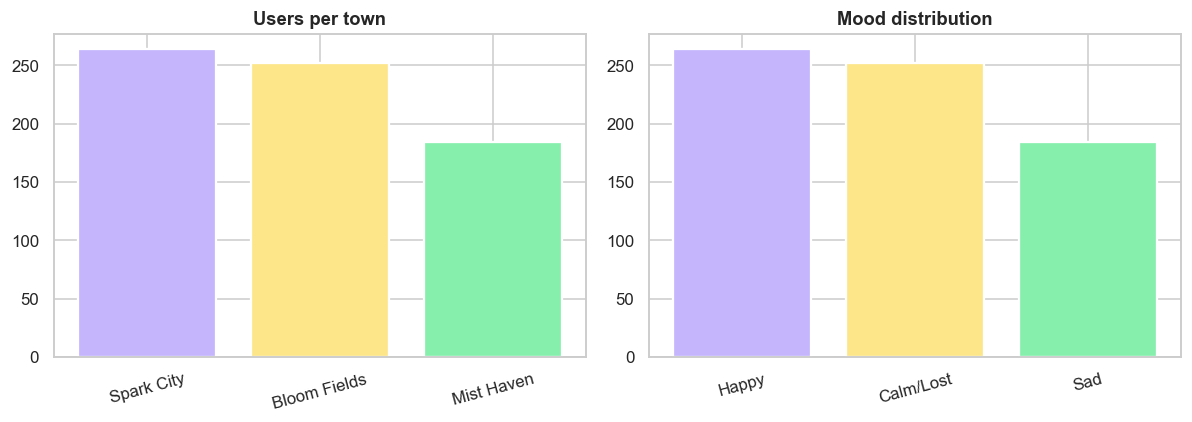

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

town_counts = df['target_town'].value_counts()
axes[0].bar(town_counts.index, town_counts.values,
            color=['#C4B5FD','#FDE68A','#86EFAC'],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Users per town', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

MOOD_LABELS = {0:'Sad', 1:'Happy', 2:'Calm/Lost'}
mood_counts = df['mood_id'].map(MOOD_LABELS).value_counts()
axes[1].bar(mood_counts.index, mood_counts.values,
            color=['#C4B5FD','#FDE68A','#86EFAC'],
            edgecolor='white', linewidth=1.5)
axes[1].set_title('Mood distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**Note**

Both charts reflect the user-centric data.

- **Users per town** — bars are *unequal* and that is expected. With personality profiles, each user independently drifts between moods based on their type (mostly_happy, mostly_sad, mostly_calm, mixed, sad_recovering). The town distribution is a natural outcome of those choices.
- **Mood distribution** — also unequal for the same reason. No artificial balancing was applied.

**Mood × Hour heatmap**

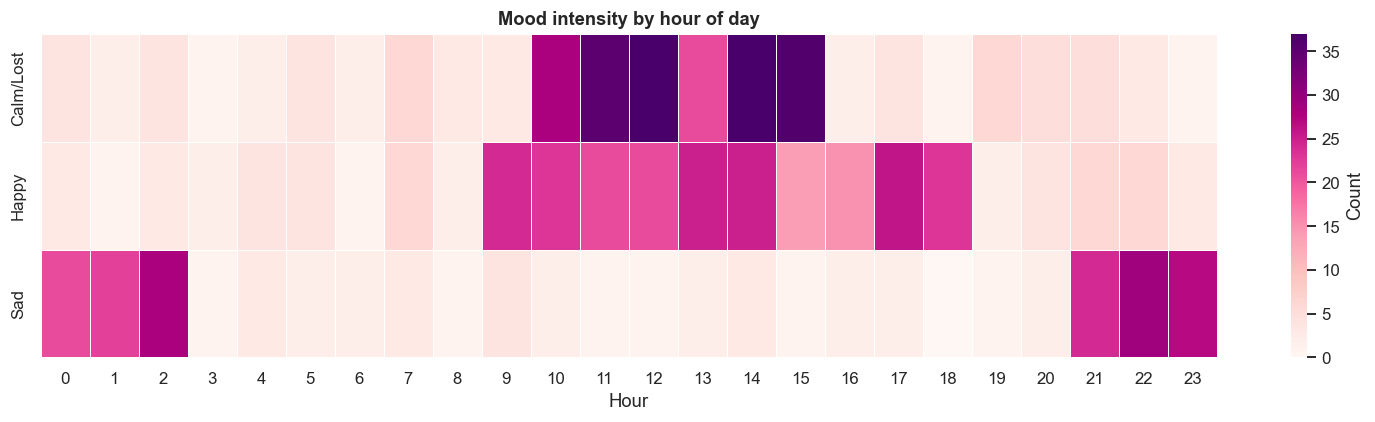

In [44]:
pivot = (df.assign(mood_label=df['mood_id'].map(MOOD_LABELS))
           .groupby(['hour_of_day', 'mood_label'])
           .size()
           .unstack(fill_value=0))

plt.figure(figsize=(14, 4))
sns.heatmap(pivot.T, cmap='RdPu', linewidths=0.4,
            cbar_kws={'label': 'Count'})
plt.title('Mood intensity by hour of day', fontweight='bold')
plt.xlabel('Hour')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Note**

The heatmap shows when each mood tends to appear across the day.

- **Sad** clusters at night and early morning (21 → 2am) — low moods tend to surface late
- **Happy** spreads across the daytime (9am → 6pm) — active, social hours
- **Calm/Lost** concentrates mid-morning (10am → 3pm) — reflective, slower pace

These patterns emerge from the `PEAK_HOURS` configuration in the data generator, which biases 70% of check-ins toward each mood's natural window.

**Hourly check-in volume (Plotly — interactive)**

In [45]:
hourly = df.groupby('hour_of_day').size().reset_index(name='count')
fig = px.area(hourly, x='hour_of_day', y='count',
              title='Check-ins by hour of day',
              labels={'hour_of_day':'Hour','count':'Check-ins'},
              color_discrete_sequence=['#C084FC'])
fig.update_traces(line_width=3, fillcolor='rgba(192,132,252,0.15)')
fig.update_layout(plot_bgcolor='rgba(0,0,0,0)', paper_bgcolor='rgba(0,0,0,0)')
fig.show()

**Note**

This chart shows overall check-in volume across the day, merging all three moods.

Because each mood has its own peak window:
- Sad peaks at night (21 → 2am)
- Happy peaks during the day (9 → 6pm)
- Calm peaks mid-morning (10 → 3pm)

The aggregate hourly curve reflects the combined weight of all personality types. The dip at night is expected, most users are `mostly_happy` or `mostly_calm`, so daytime hours dominate.

**Town × Day-of-week heatmap**

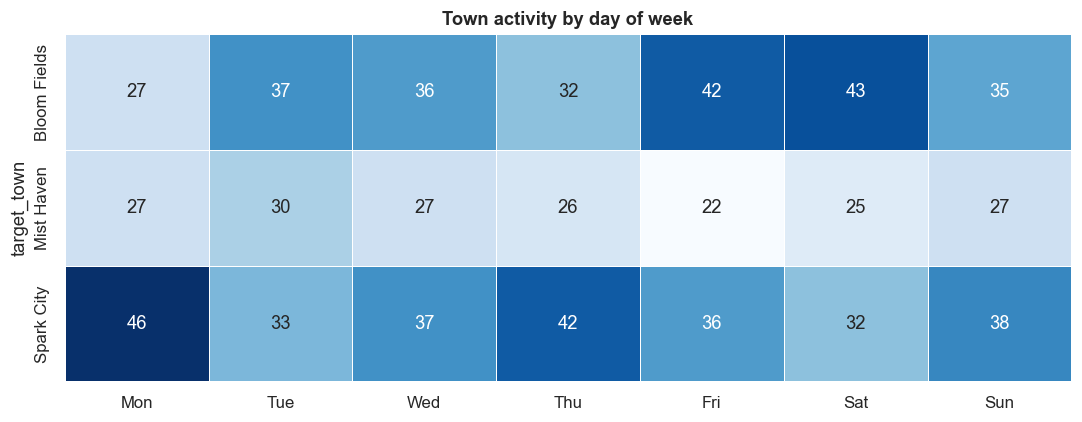

In [46]:
DAY_LABELS = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot2 = (df.groupby(['target_town','day_of_week'])
             .size()
             .unstack(fill_value=0)
             .rename(columns={i:d for i,d in enumerate(DAY_LABELS)}))

plt.figure(figsize=(10, 4))
sns.heatmap(pivot2, cmap='Blues', annot=True, fmt='d',
            linewidths=0.5, cbar=False)
plt.title('Town activity by day of week', fontweight='bold')
plt.xlabel('')
plt.tight_layout()
plt.show()

**Note**

This heatmap counts check-ins per town per day of the week.

With this user-centric generator, all three towns spread fairly evenly across all 7 days. The slight variation between days is natural randomness from personality-driven mood selection. The stronger patterns for any town, reflects the personality mix of users in that town rather than a design rule.

## 4 · Feature Engineering

In [55]:
X = df[['mood_id', 'hour_of_day', 'day_of_week']].values
y = df['target_town'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes: {np.unique(y)}')

Train: (560, 3)  |  Test: (140, 3)
Classes: ['Bloom Fields' 'Mist Haven' 'Spark City']


## 5 · Model Training

We compare **RandomForestClassifier** vs **XGBClassifier**.
Both expose `predict_proba()`

In [56]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, max_depth=12,
    min_samples_leaf=2, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Random Forest  — Weighted F1: {f1_rf:.4f}')

Random Forest  — Weighted F1: 1.0000


In [57]:
# XGBoost
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200, max_depth=6,
    learning_rate=0.1, use_label_encoder=False,
    eval_metric='mlogloss', random_state=42,
    n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train_enc)
y_pred_xgb_enc = xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
print(f'XGBoost        — Weighted F1: {f1_xgb:.4f}')

XGBoost        — Weighted F1: 1.0000


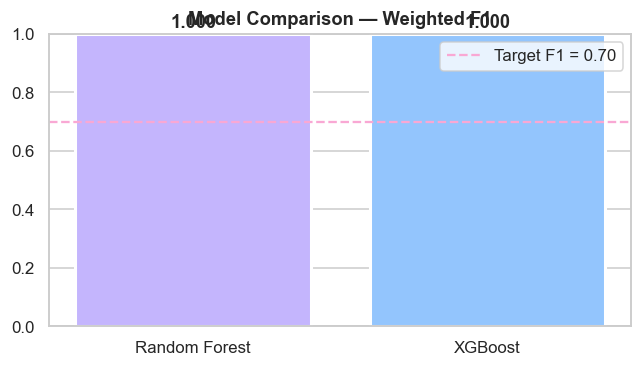

Best model: RF


In [58]:
# Model comparison bar chart
models = ['Random Forest', 'XGBoost']
scores = [f1_rf, f1_xgb]
colors = ['#C4B5FD', '#93C5FD']
best   = 'rf' if f1_rf >= f1_xgb else 'xgb'

plt.figure(figsize=(6, 3.5))
bars = plt.bar(models, scores, color=colors, edgecolor='white', linewidth=2)
plt.ylim(0, 1.0)
plt.axhline(0.70, color='#F9A8D4', linestyle='--', linewidth=1.5, label='Target F1 = 0.70')
for bar, s in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, s + 0.02,
             f'{s:.3f}', ha='center', fontweight='bold')
plt.title('Model Comparison — Weighted F1', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()
print(f'Best model: {best.upper()}')

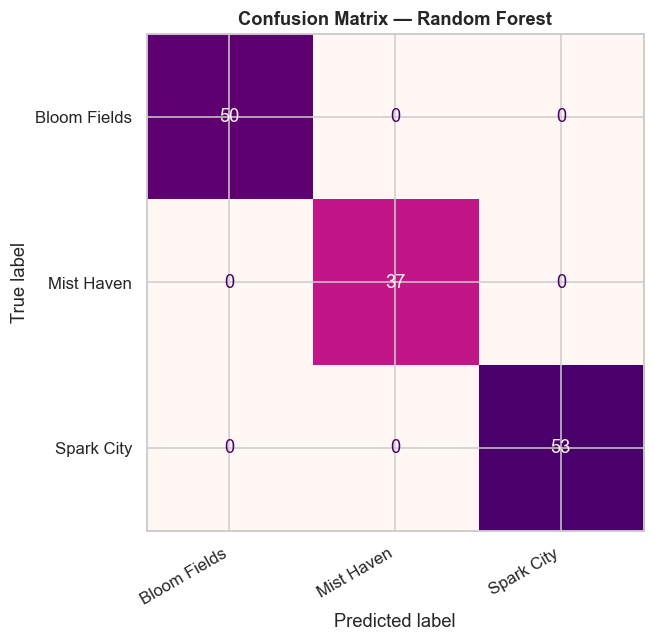

In [59]:
# Confusion matrix for the best model
best_model  = rf if best == 'rf' else xgb
best_y_pred = y_pred_rf if best == 'rf' else y_pred_xgb

cm     = confusion_matrix(y_test, best_y_pred, labels=rf.classes_)
fig, ax = plt.subplots(figsize=(8, 6))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                 display_labels=rf.classes_)
disp.plot(ax=ax, cmap='RdPu', colorbar=False)
plt.title(f'Confusion Matrix — {"Random Forest" if best=="rf" else "XGBoost"}',
          fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

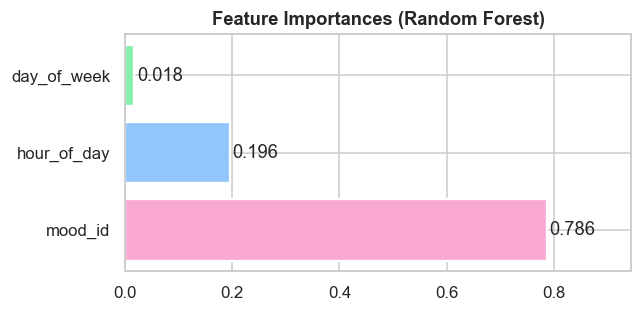

In [62]:
# Feature importance (RF only)
feature_names = ['mood_id', 'hour_of_day', 'day_of_week']
importances   = rf.feature_importances_

plt.figure(figsize=(6, 3))
bars = plt.barh(feature_names, importances,
                color=['#F9A8D4','#93C5FD','#86EFAC'],
                edgecolor='white', linewidth=1.5)
for bar, imp in zip(bars, importances):
    plt.text(imp + 0.005, bar.get_y() + bar.get_height()/2,
             f'{imp:.3f}', va='center')
plt.title('Feature Importances (Random Forest)', fontweight='bold')
plt.xlim(0, max(importances) * 1.2)
plt.tight_layout()
plt.show()

In [63]:
print('Full Classification Report (best model):')
print(classification_report(y_test, best_y_pred))

Full Classification Report (best model):
              precision    recall  f1-score   support

Bloom Fields       1.00      1.00      1.00        50
  Mist Haven       1.00      1.00      1.00        37
  Spark City       1.00      1.00      1.00        53

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



**note**

The dataset is synthetically generated and contains strong deterministic patterns, resulting in perfect separability. Real-world user-generated data would introduce noise, ambiguity, and distribution shift.

While both ensemble models achieve perfect performance on the synthetic dataset, this reflects controlled feature construction rather than true predictive robustness. Evaluation on real-world data is required to assess generalisation

## 6 · Export Model

In [64]:
# Export RF (always deploy RF for fast inference; XGBoost is the benchmark)
joblib.dump({'model': rf, 'scaler': scaler}, 'models/mood_model.joblib')
print('Saved  →  models/mood_model.joblib')

# Sanity check: predict one sample
import datetime
now      = datetime.datetime.now()
sample   = np.array([[0, now.hour, now.weekday()]])  # mood=Sad
scaled   = scaler.transform(sample)
proba    = rf.predict_proba(scaled)[0]
top_idx  = np.argmax(proba)
print(f'\nTest prediction for mood=Sad:')
for cls, p in sorted(zip(rf.classes_, proba), key=lambda x: -x[1]):
    print(f'  {cls:<16} {p*100:5.1f}%')

Saved  →  models/mood_model.joblib

Test prediction for mood=Sad:
  Mist Haven        88.2%
  Spark City        10.0%
  Bloom Fields       1.8%


## 7 · Town Wordclouds

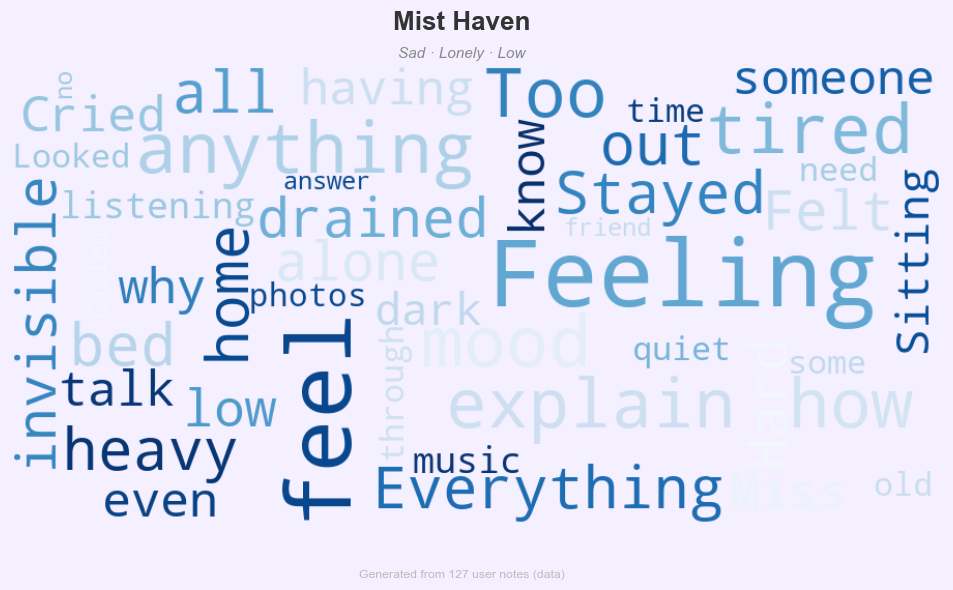

Saved -> assets/wordclouds/mist_haven.png  [127 notes, source: data]


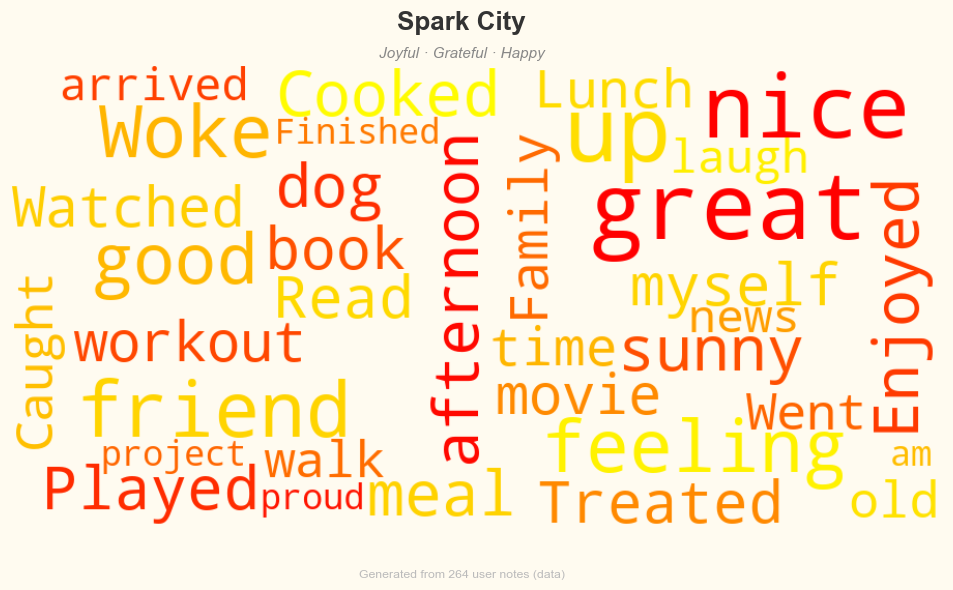

Saved -> assets/wordclouds/spark_city.png  [264 notes, source: data]


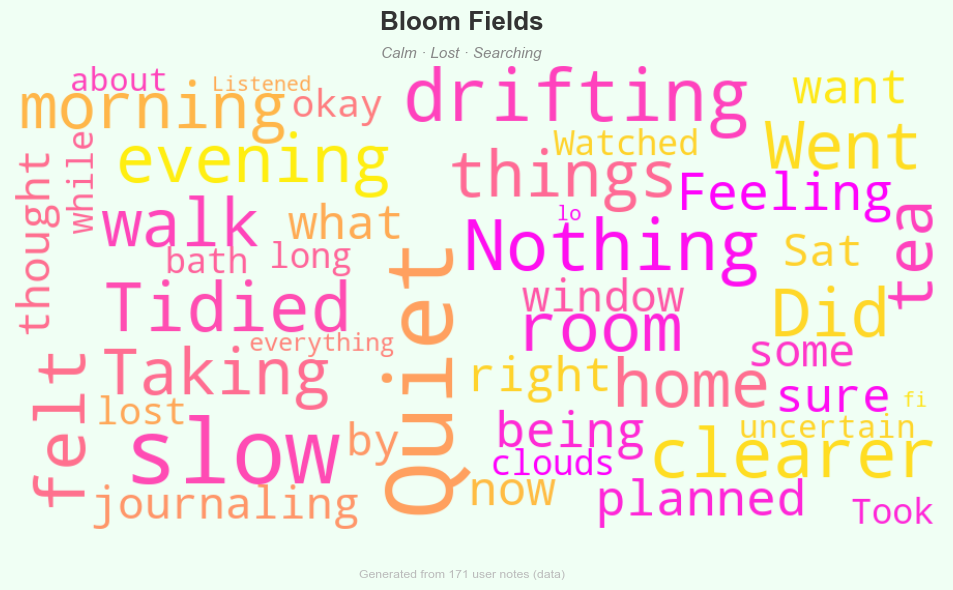

Saved -> assets/wordclouds/bloom_fields.png  [171 notes, source: data]

All town wordclouds generated


In [65]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Words to ignore — too common to be meaningful in a wordcloud
STOPWORDS = {
    'a','an','the','and','or','but','in','on','at','to','for','of','with',
    'my','i','it','is','was','not','so','just','really','got','get','had',
    'have','been','get','going','today','day','bit','something','didn',
    'couldn','didn','didn\'t','couldn\'t','t','s','don','didn','i','ve','re',
}

TOWN_CONFIG = {
    'Mist Haven':   {'colormap': 'Blues',  'bg': '#F5F0FF', 'subtitle': 'Sad · Lonely · Low'},
    'Spark City':   {'colormap': 'autumn', 'bg': '#FFFBF0', 'subtitle': 'Joyful · Grateful · Happy'},
    'Bloom Fields': {'colormap': 'spring', 'bg': '#F0FFF4', 'subtitle': 'Calm · Lost · Searching'},
}

for town_name, config in TOWN_CONFIG.items():

    # ── Pull notes from the dataset for this town ──────────────────────────
    notes = df[df['target_town'] == town_name]['note'].dropna().tolist()
    data_text = ' '.join(notes)

    # ── Fall back to hardcoded text if not enough data ─────────────────────
    FALLBACK = {
        'Mist Haven':   'sad lonely low heavy ache cry tears empty hollow missing someone down blue melancholy grey morning invisible tired soft day not ready numb sadness slow breathing gentle kindness tender bruised still surviving you are not alone healing slowly',
        'Spark City':   'joyful grateful excited proud peaceful happy radiant glow thankful celebration achievement alive thriving content blessed abundance fulfilled savour smile warmth sunshine good mood positive energy uplifted inspired glad cheerful delighted optimistic laughter accomplished glowing',
        'Bloom Fields': 'calm still quiet unclear searching uncertain maybe tomorrow somewhere forward path not sure yet okay drifting gentle pace slow morning tea steady lost but okay peace not rushing curious open possibilities discovering becoming soft landing place',
    }

    text = data_text if len(data_text.split()) >= 30 else FALLBACK[town_name]

    # ── Generate wordcloud ─────────────────────────────────────────────────
    wc = WordCloud(
        width=900, height=450,
        background_color=config['bg'],
        colormap=config['colormap'],
        max_words=60,
        prefer_horizontal=0.85,
        stopwords=STOPWORDS,
        collocations=False,
        min_font_size=11,
        max_font_size=90,
        relative_scaling=0.55,
    ).generate(text)

    source = 'data' if len(data_text.split()) >= 30 else 'fallback'

    fig, ax = plt.subplots(figsize=(11, 5.5))
    fig.patch.set_facecolor(config['bg'])
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    fig.text(0.5, 0.97, town_name, ha='center', va='top',
             fontsize=17, fontweight='bold', color='#333')
    fig.text(0.5, 0.91, config['subtitle'], ha='center', va='top',
             fontsize=10, color='#888', style='italic')
    fig.text(0.5, 0.03, f'Generated from {len(notes)} user notes ({source})',
             ha='center', va='bottom', fontsize=8, color='#BBB')

    filename = town_name.lower().replace(' ', '_')
    path = f'assets/wordclouds/{filename}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=config['bg'])
    plt.show()
    plt.close()
    print(f'Saved -> {path}  [{len(notes)} notes, source: {source}]')

print('\nAll town wordclouds generated')

**note**

The wordcloud images are static files generated once per town, shipped as PNG assets for the frontend.